# Predicting Adult Mortality Rate in African Nations

**Mission:** Premature adult deaths (ages 15-60) remain one of the biggest barriers to economic growth across Africa. This notebook builds a regression model to predict the Adult Mortality Rate using health, economic, and social indicators from the WHO dataset.

**Dataset Source:** [WHO Life Expectancy Dataset on Kaggle](https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who) — 2,938 records across 193 countries from 2000 to 2015.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
import joblib
import warnings
warnings.filterwarnings('ignore')

## 2. Load the Dataset

In [4]:
df = pd.read_csv('Life_Expectancy_Data.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [6]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


## 3. Filter for African Countries

Since our mission focuses on Africa, I will filter the dataset to only include African nations. This makes the model more specific and relevant to our use case.

In [7]:
african_countries = [
    'Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi',
    'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros',
    'Congo', 'Côte d\'Ivoire', "Cote d'Ivoire", 'Democratic Republic of the Congo',
    'Djibouti', 'Egypt', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia',
    'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya',
    'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali',
    'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger',
    'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles',
    'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan',
    'Swaziland', 'Togo', 'Tunisia', 'Uganda', 'United Republic of Tanzania',
    'Zambia', 'Zimbabwe', 'Tanzania'
]

# Strip whitespace from country names in the dataset
df['Country'] = df['Country'].str.strip()

# Filter
africa_df = df[df['Country'].isin(african_countries)].copy()
print(f"African countries found: {africa_df['Country'].nunique()}")
print(f"Total records for Africa: {africa_df.shape[0]}")
print(f"\nCountries included:")
print(sorted(africa_df['Country'].unique()))

African countries found: 54
Total records for Africa: 864

Countries included:
['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo', "Côte d'Ivoire", 'Democratic Republic of the Congo', 'Djibouti', 'Egypt', 'Equatorial Guinea', 'Eritrea', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Swaziland', 'Togo', 'Tunisia', 'Uganda', 'United Republic of Tanzania', 'Zambia', 'Zimbabwe']


## 4. Exploratory Data Analysis (EDA)

Let's look at the data more closely to understand what we are working with.

In [8]:
# Check for missing values
missing = africa_df.isnull().sum()
missing_pct = (missing / len(africa_df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})

print("Missing values in our African dataset:")
missing_info[missing_info['Missing Count'] > 0].sort_values('Missing %', ascending=False)

Missing values in our African dataset:


,Missing Count,Missing %
Hepatitis B,234,27.08
Population,132,15.28
GDP,126,14.58
Total expenditure,81,9.38
Alcohol,69,7.99
Schooling,64,7.41
Income composition of resources,64,7.41
BMI,32,3.70
thinness 1-19 years,32,3.70
thinness 5-9 years,32,3.70


### 4.1 Distribution of Adult Mortality (our target variable)

Understanding the shape of what we are predicting is important before we start modeling.

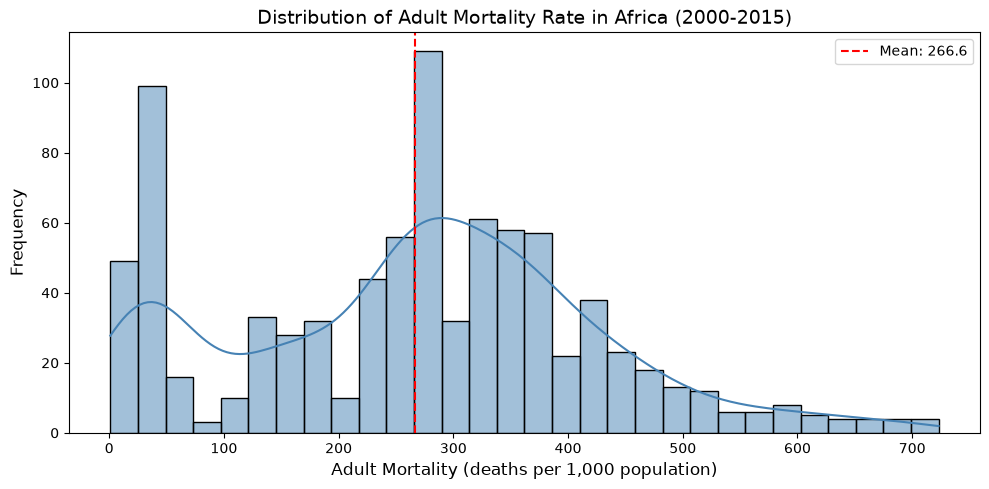

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(africa_df['Adult Mortality'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('Distribution of Adult Mortality Rate in Africa (2000-2015)', fontsize=14)
plt.xlabel('Adult Mortality (deaths per 1,000 population)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(africa_df['Adult Mortality'].mean(), color='red', linestyle='--', label=f"Mean: {africa_df['Adult Mortality'].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The distribution of adult mortality in Africa tends to be right-skewed, with a significant number of countries experiencing high mortality rates. The mean gives us a baseline to compare our model predictions against.

### 4.2 Correlation Heatmap

This helps us see which features have the strongest relationship with Adult Mortality.

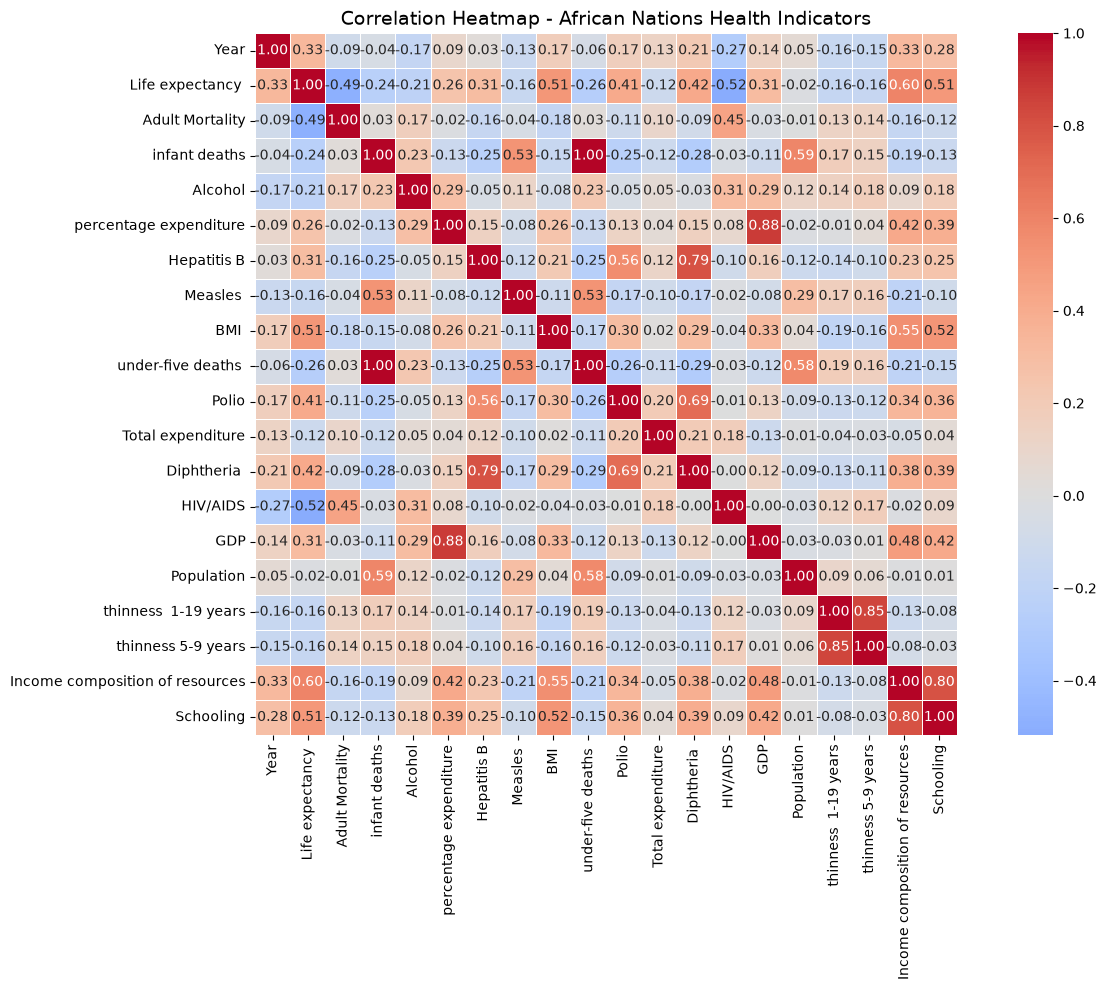

In [10]:
# Get only numeric columns for the correlation
numeric_cols = africa_df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - African Nations Health Indicators', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Let's specifically see which features correlate most with Adult Mortality
target_corr = corr_matrix['Adult Mortality'].drop('Adult Mortality').sort_values(ascending=False)
print("Correlation with Adult Mortality:")
print("=" * 45)
for feature, corr_val in target_corr.items():
    direction = "positive" if corr_val > 0 else "negative"
    print(f"{feature:>40s}: {corr_val:+.3f} ({direction})")

Correlation with Adult Mortality:
                                HIV/AIDS: +0.448 (positive)
                                 Alcohol: +0.168 (positive)
                      thinness 5-9 years: +0.140 (positive)
                    thinness  1-19 years: +0.129 (positive)
                       Total expenditure: +0.096 (positive)
                      under-five deaths : +0.033 (positive)
                           infant deaths: +0.033 (positive)
                              Population: -0.006 (negative)
                  percentage expenditure: -0.015 (negative)
                                     GDP: -0.034 (negative)
                                Measles : -0.044 (negative)
                             Diphtheria : -0.088 (negative)
                                    Year: -0.095 (negative)
                                   Polio: -0.110 (negative)
                               Schooling: -0.118 (negative)
                             Hepatitis B: -0.158 (negative)
      

**Interpretation:** Features like HIV/AIDS, Income Composition, and Schooling tend to have strong correlations with Adult Mortality. Variables that are highly correlated with each other (like infant deaths and under-five deaths) may cause multicollinearity, so we should consider dropping one of them.

### 4.3 Scatter Plots - Key Relationships

Let me visualize a few of the most important relationships.

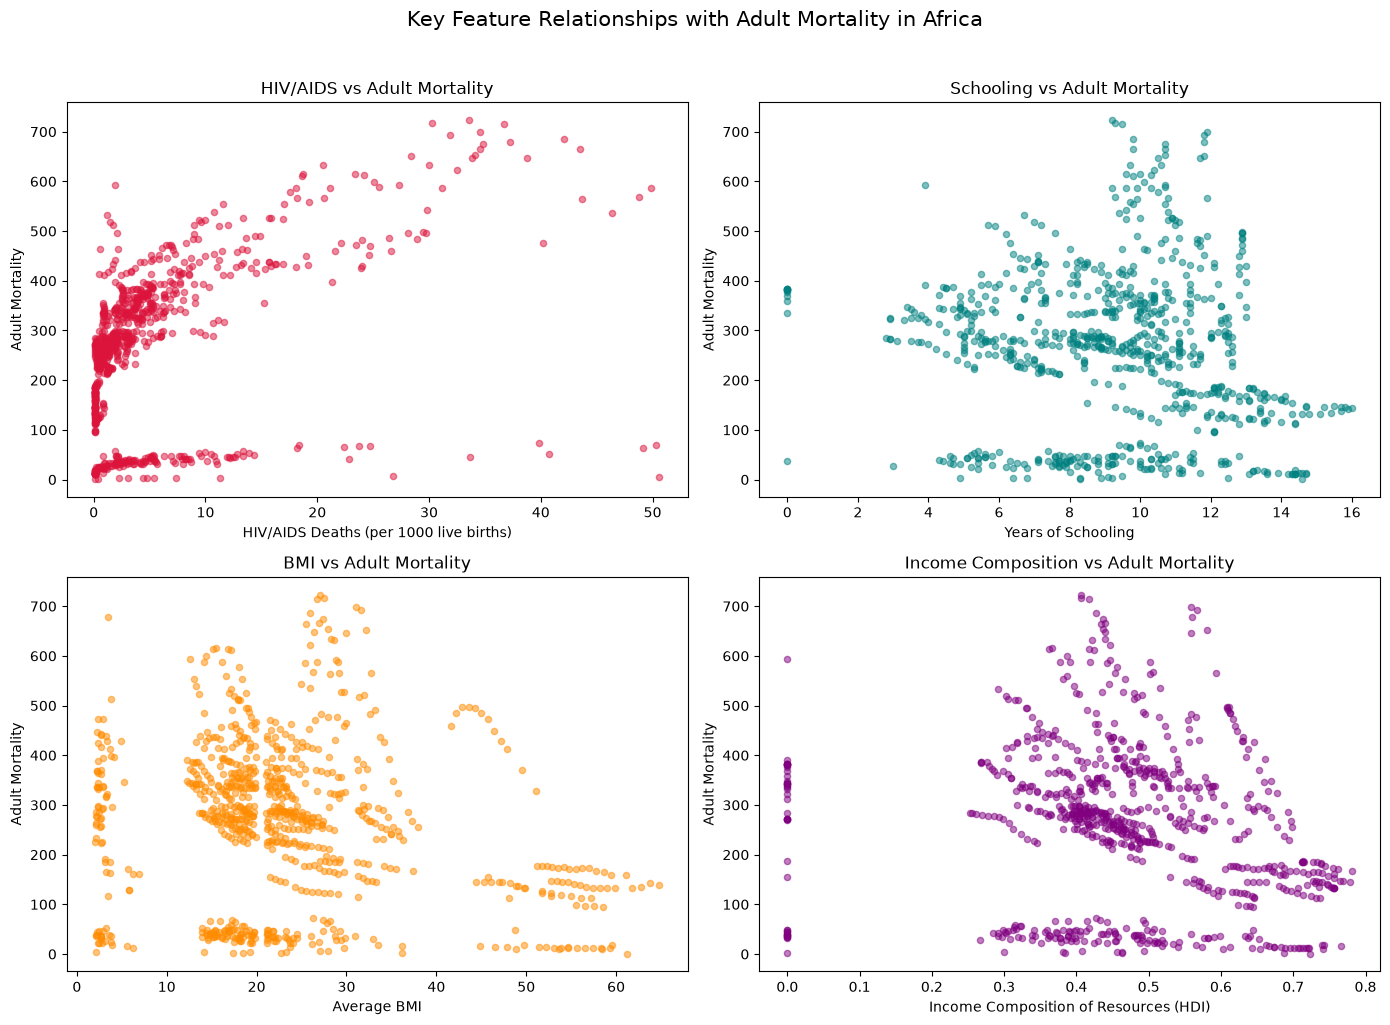

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# HIV/AIDS vs Adult Mortality
axes[0, 0].scatter(africa_df[' HIV/AIDS'], africa_df['Adult Mortality'], alpha=0.5, color='crimson', s=20)
axes[0, 0].set_xlabel('HIV/AIDS Deaths (per 1000 live births)')
axes[0, 0].set_ylabel('Adult Mortality')
axes[0, 0].set_title('HIV/AIDS vs Adult Mortality')

# Schooling vs Adult Mortality
axes[0, 1].scatter(africa_df['Schooling'], africa_df['Adult Mortality'], alpha=0.5, color='teal', s=20)
axes[0, 1].set_xlabel('Years of Schooling')
axes[0, 1].set_ylabel('Adult Mortality')
axes[0, 1].set_title('Schooling vs Adult Mortality')

# BMI vs Adult Mortality
axes[1, 0].scatter(africa_df[' BMI '], africa_df['Adult Mortality'], alpha=0.5, color='darkorange', s=20)
axes[1, 0].set_xlabel('Average BMI')
axes[1, 0].set_ylabel('Adult Mortality')
axes[1, 0].set_title('BMI vs Adult Mortality')

# Income Composition vs Adult Mortality
axes[1, 1].scatter(africa_df['Income composition of resources'], africa_df['Adult Mortality'], alpha=0.5, color='purple', s=20)
axes[1, 1].set_xlabel('Income Composition of Resources (HDI)')
axes[1, 1].set_ylabel('Adult Mortality')
axes[1, 1].set_title('Income Composition vs Adult Mortality')

plt.suptitle('Key Feature Relationships with Adult Mortality in Africa', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:**
- **HIV/AIDS** has a clear positive relationship — countries with higher HIV death rates have higher adult mortality.
- **Schooling** and **Income composition** show negative trends — more education and higher HDI are associated with lower mortality.
- **BMI** shows a moderate negative pattern — lower average BMI (malnutrition) is linked to higher adult mortality.

## 5. Feature Engineering & Data Preprocessing

Now I need to prepare the data for modeling. This involves:
1. Handling missing values
2. Converting categorical data to numeric
3. Dropping columns that won't help the model
4. Standardizing the features

In [13]:
# Make a working copy
data = africa_df.copy()

# Drop rows where our target variable is missing - can't train without it
data = data.dropna(subset=['Adult Mortality'])
print(f"Rows after dropping missing target: {len(data)}")

Rows after dropping missing target: 864


In [14]:
# Convert 'Status' column from text to numeric
# Developing = 0, Developed = 1
label_enc = LabelEncoder()
data['Status'] = label_enc.fit_transform(data['Status'])
print("Status encoding:")
print(dict(zip(label_enc.classes_, label_enc.transform(label_enc.classes_))))

Status encoding:
{'Developing': np.int64(0)}


In [15]:
# Drop columns that don't help with prediction
# - 'Country' is a name, not a number the model can learn from
# - 'under-five deaths' is very highly correlated with 'infant deaths' (multicollinearity)
# - 'thinness 5-9 years' is very correlated with 'thinness 1-19 years'
# - 'Life expectancy' would leak information since it's directly related to our target

columns_to_drop = ['Country', 'under-five deaths ', ' thinness 5-9 years', 'Life expectancy ']

data = data.drop(columns=columns_to_drop)
print(f"Remaining columns ({len(data.columns)}):")
print(list(data.columns))

Remaining columns (18):
['Year', 'Status', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', 'Income composition of resources', 'Schooling']


In [16]:
# Fill remaining missing values with the column median
# Median is better than mean for skewed data because it's not affected by outliers

for col in data.columns:
    if data[col].isnull().sum() > 0:
        median_val = data[col].median()
        data[col] = data[col].fillna(median_val)
        print(f"Filled {col} missing values with median: {median_val:.2f}")

print(f"\nTotal missing values remaining: {data.isnull().sum().sum()}")

Filled Alcohol missing values with median: 1.52
Filled Hepatitis B missing values with median: 84.00
Filled  BMI  missing values with median: 21.30
Filled Polio missing values with median: 78.00
Filled Total expenditure missing values with median: 5.12
Filled Diphtheria  missing values with median: 79.00
Filled GDP missing values with median: 533.87
Filled Population missing values with median: 1581720.00
Filled  thinness  1-19 years missing values with median: 7.40
Filled Income composition of resources missing values with median: 0.46
Filled Schooling missing values with median: 9.55

Total missing values remaining: 0


In [17]:
# Separate features (X) and target (y)
X = data.drop('Adult Mortality', axis=1)
y = data['Adult Mortality']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (864, 17)
Target shape: (864,)

Feature columns: ['Year', 'Status', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', 'Income composition of resources', 'Schooling']


In [18]:
# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 691 samples
Testing set: 173 samples


In [19]:
# Standardize the features
# This puts all features on the same scale so no single feature dominates

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardization complete.")
print(f"Example - Before scaling (first row): {X_train.iloc[0].values[:5]}")
print(f"Example - After scaling (first row):  {X_train_scaled[0][:5]}")

Standardization complete.
Example - Before scaling (first row): [2.0040000e+03 0.0000000e+00 2.4000000e+01 3.5000000e-01 6.6022363e+01]
Example - After scaling (first row):  [-0.75607031  0.         -0.23092029 -0.79711603 -0.19265952]


## 6. Model Training & Comparison

I will train 4 different regression models and compare them:
1. **SGD Regressor** (Stochastic Gradient Descent Linear Regression)
2. **Linear Regression** (Ordinary Least Squares)
3. **Random Forest Regressor** (Ensemble method)
4. **Decision Tree Regressor** (Tree-based method)

### 6.1 Stochastic Gradient Descent (SGD) Linear Regression

In [20]:
# SGD Regressor - this uses gradient descent to optimize the linear regression
sgd_model = SGDRegressor(
    max_iter=1000,
    learning_rate='adaptive',
    eta0=0.01,
    random_state=42
)

sgd_model.fit(X_train_scaled, y_train)

sgd_train_pred = sgd_model.predict(X_train_scaled)
sgd_test_pred = sgd_model.predict(X_test_scaled)

print("SGD Linear Regression Results:")
print(f"  Train MSE: {mean_squared_error(y_train, sgd_train_pred):.2f}")
print(f"  Test MSE:  {mean_squared_error(y_test, sgd_test_pred):.2f}")
print(f"  Test MAE:  {mean_absolute_error(y_test, sgd_test_pred):.2f}")
print(f"  Test R²:   {r2_score(y_test, sgd_test_pred):.4f}")

SGD Linear Regression Results:
  Train MSE: 17639.67
  Test MSE:  20690.11
  Test MAE:  103.16
  Test R²:   0.1844


### 6.2 Linear Regression (Ordinary Least Squares)

In [21]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred = lr_model.predict(X_test_scaled)

print("Linear Regression (OLS) Results:")
print(f"  Train MSE: {mean_squared_error(y_train, lr_train_pred):.2f}")
print(f"  Test MSE:  {mean_squared_error(y_test, lr_test_pred):.2f}")
print(f"  Test MAE:  {mean_absolute_error(y_test, lr_test_pred):.2f}")
print(f"  Test R²:   {r2_score(y_test, lr_test_pred):.4f}")

Linear Regression (OLS) Results:
  Train MSE: 17639.39
  Test MSE:  20690.96
  Test MAE:  103.24
  Test R²:   0.1844


### 6.3 Random Forest Regressor

In [22]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred = rf_model.predict(X_test_scaled)

print("Random Forest Results:")
print(f"  Train MSE: {mean_squared_error(y_train, rf_train_pred):.2f}")
print(f"  Test MSE:  {mean_squared_error(y_test, rf_test_pred):.2f}")
print(f"  Test MAE:  {mean_absolute_error(y_test, rf_test_pred):.2f}")
print(f"  Test R²:   {r2_score(y_test, rf_test_pred):.4f}")

Random Forest Results:
  Train MSE: 3401.87
  Test MSE:  18231.76
  Test MAE:  90.30
  Test R²:   0.2813


### 6.4 Decision Tree Regressor

In [23]:
dt_model = DecisionTreeRegressor(
    max_depth=8,
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)

dt_train_pred = dt_model.predict(X_train_scaled)
dt_test_pred = dt_model.predict(X_test_scaled)

print("Decision Tree Results:")
print(f"  Train MSE: {mean_squared_error(y_train, dt_train_pred):.2f}")
print(f"  Test MSE:  {mean_squared_error(y_test, dt_test_pred):.2f}")
print(f"  Test MAE:  {mean_absolute_error(y_test, dt_test_pred):.2f}")
print(f"  Test R²:   {r2_score(y_test, dt_test_pred):.4f}")

Decision Tree Results:
  Train MSE: 5949.67
  Test MSE:  27485.72
  Test MAE:  107.51
  Test R²:   -0.0834


### 6.5 Model Comparison Summary

In [24]:
# Put all results in a table so we can compare easily
results = {
    'Model': ['SGD Linear Regression', 'Linear Regression (OLS)', 'Random Forest', 'Decision Tree'],
    'Train MSE': [
        mean_squared_error(y_train, sgd_train_pred),
        mean_squared_error(y_train, lr_train_pred),
        mean_squared_error(y_train, rf_train_pred),
        mean_squared_error(y_train, dt_train_pred)
    ],
    'Test MSE': [
        mean_squared_error(y_test, sgd_test_pred),
        mean_squared_error(y_test, lr_test_pred),
        mean_squared_error(y_test, rf_test_pred),
        mean_squared_error(y_test, dt_test_pred)
    ],
    'Test MAE': [
        mean_absolute_error(y_test, sgd_test_pred),
        mean_absolute_error(y_test, lr_test_pred),
        mean_absolute_error(y_test, rf_test_pred),
        mean_absolute_error(y_test, dt_test_pred)
    ],
    'Test R²': [
        r2_score(y_test, sgd_test_pred),
        r2_score(y_test, lr_test_pred),
        r2_score(y_test, rf_test_pred),
        r2_score(y_test, dt_test_pred)
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test MSE', ascending=True)
results_df

,Model,Train MSE,Test MSE,Test MAE,Test R²
2,Random Forest,3401.871759,18231.762972,90.301702,0.281336
0,SGD Linear Regression,17639.673607,20690.114967,103.161905,0.184433
1,Linear Regression (OLS),17639.390470,20690.960603,103.236589,0.184399
3,Decision Tree,5949.671339,27485.718570,107.505593,-0.083438


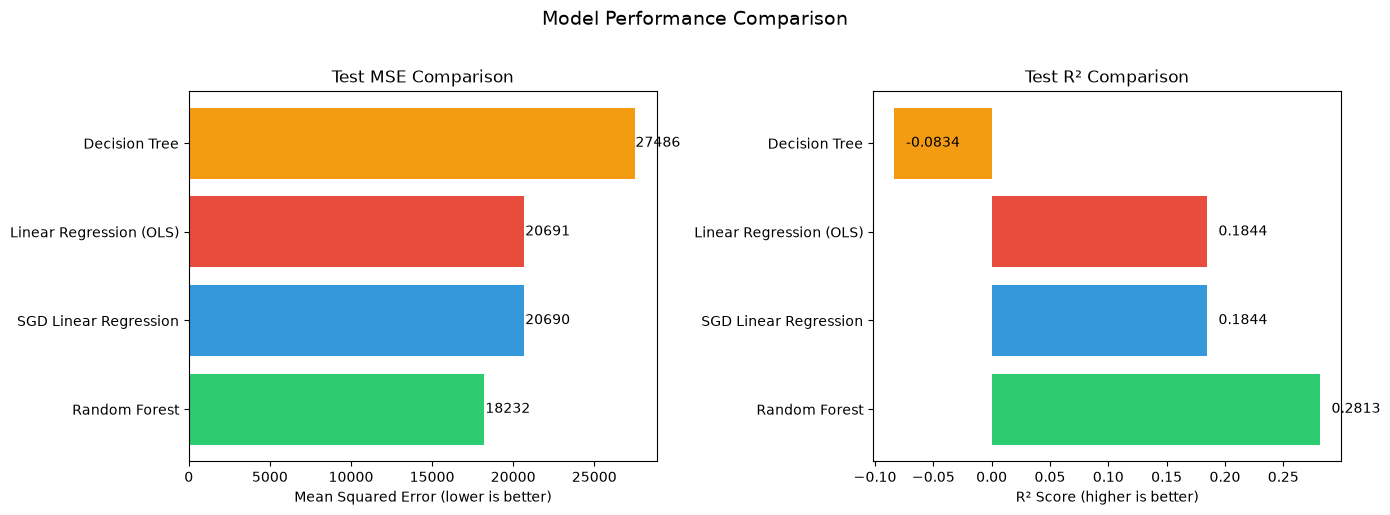

In [25]:
# Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = results_df['Model']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

# MSE comparison
bars1 = axes[0].barh(models, results_df['Test MSE'], color=colors)
axes[0].set_xlabel('Mean Squared Error (lower is better)')
axes[0].set_title('Test MSE Comparison')
for bar, val in zip(bars1, results_df['Test MSE']):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}', va='center', fontsize=10)

# R² comparison
bars2 = axes[1].barh(models, results_df['Test R²'], color=colors)
axes[1].set_xlabel('R² Score (higher is better)')
axes[1].set_title('Test R² Comparison')
for bar, val in zip(bars2, results_df['Test R²']):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Loss Curves (Train vs Test)

Let me train the SGD model incrementally to show how the loss decreases over epochs.

In [26]:
# Track loss over training epochs for SGD
train_losses = []
test_losses = []

sgd_tracking = SGDRegressor(
    max_iter=1,
    warm_start=True,
    learning_rate='adaptive',
    eta0=0.01,
    random_state=42
)

epochs = 150
for epoch in range(1, epochs + 1):
    sgd_tracking.fit(X_train_scaled, y_train)
    
    train_pred = sgd_tracking.predict(X_train_scaled)
    test_pred = sgd_tracking.predict(X_test_scaled)
    
    train_loss = mean_squared_error(y_train, train_pred)
    test_loss = mean_squared_error(y_test, test_pred)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)

print(f"Final Train Loss: {train_losses[-1]:.2f}")
print(f"Final Test Loss: {test_losses[-1]:.2f}")

Final Train Loss: 18898.07
Final Test Loss: 22799.85


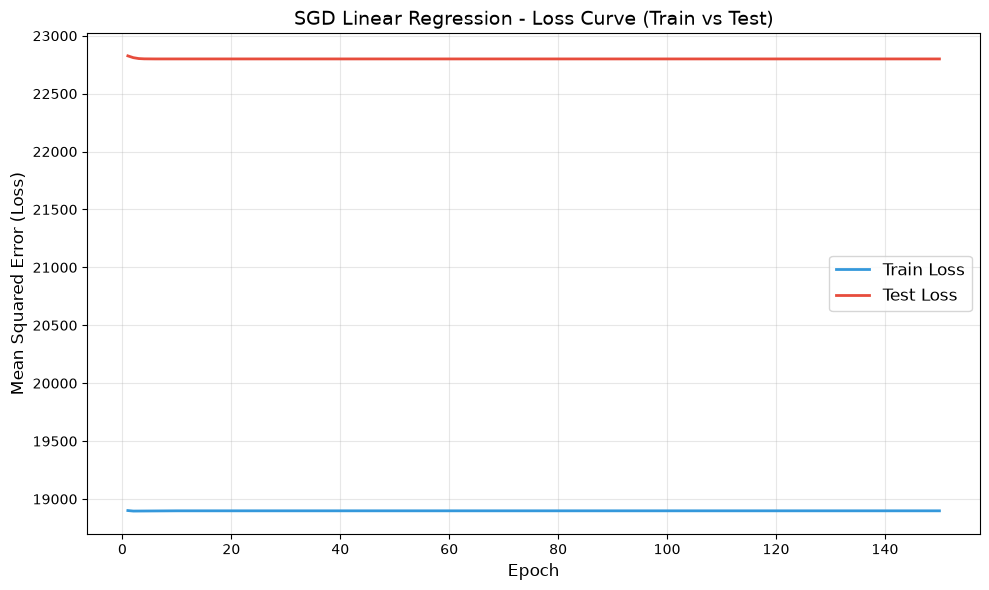

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', color='#3498db', linewidth=2)
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss', color='#e74c3c', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Squared Error (Loss)', fontsize=12)
plt.title('SGD Linear Regression - Loss Curve (Train vs Test)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:** Both train and test loss decrease and converge, which shows the model is learning properly without overfitting. If the test loss started going back up while train loss kept going down, that would indicate overfitting.

## 8. Scatter Plot — Before and After (Best Fit Line)

Showing where the linear regression line passes through the data.

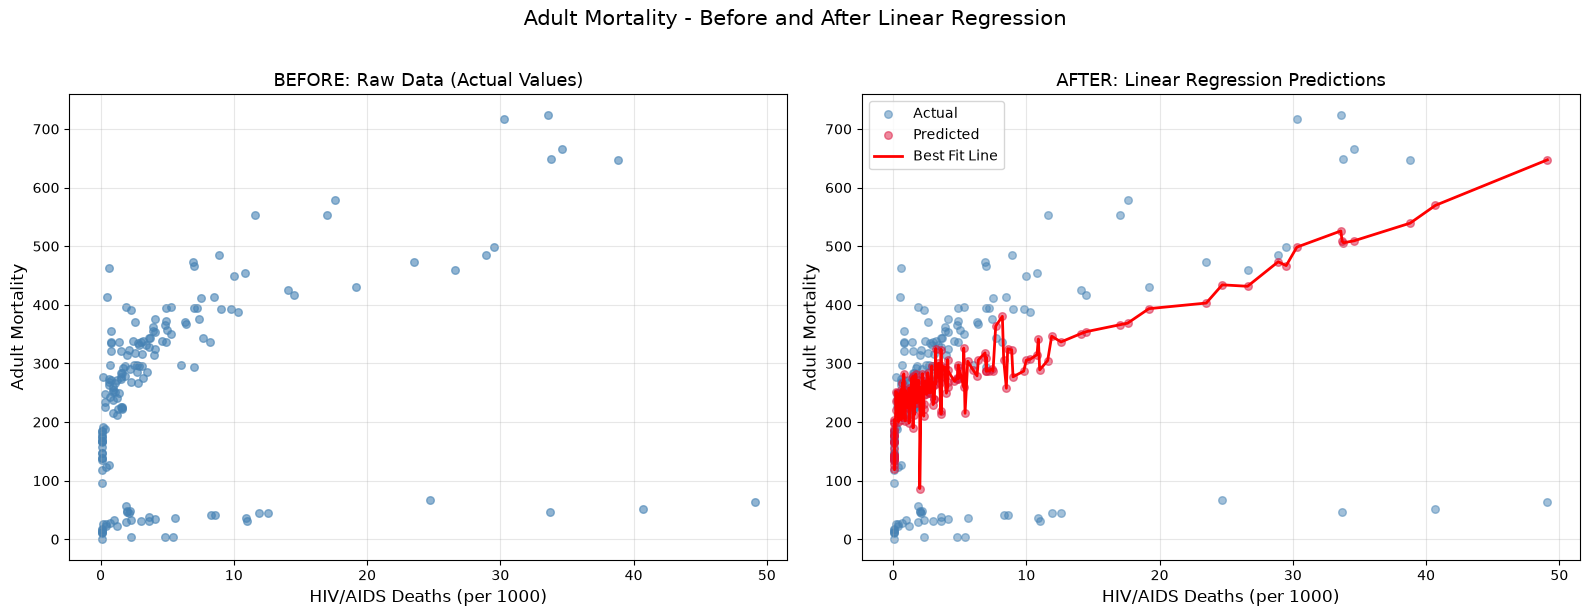

In [28]:
# Use the best linear model's predictions for this plot
# We'll use the OLS Linear Regression predictions

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before - Actual data scatter (using HIV/AIDS as example feature)
axes[0].scatter(X_test[' HIV/AIDS'], y_test, alpha=0.6, color='steelblue', s=30)
axes[0].set_xlabel('HIV/AIDS Deaths (per 1000)', fontsize=12)
axes[0].set_ylabel('Adult Mortality', fontsize=12)
axes[0].set_title('BEFORE: Raw Data (Actual Values)', fontsize=13)
axes[0].grid(True, alpha=0.3)

# After - With the linear regression predictions and best fit line
axes[1].scatter(X_test[' HIV/AIDS'], y_test, alpha=0.5, color='steelblue', s=30, label='Actual')
axes[1].scatter(X_test[' HIV/AIDS'], lr_test_pred, alpha=0.5, color='crimson', s=30, label='Predicted')

# Draw the best fit line through predictions
sort_idx = X_test[' HIV/AIDS'].argsort()
axes[1].plot(X_test[' HIV/AIDS'].iloc[sort_idx], lr_test_pred[sort_idx],
            color='red', linewidth=2, label='Best Fit Line')

axes[1].set_xlabel('HIV/AIDS Deaths (per 1000)', fontsize=12)
axes[1].set_ylabel('Adult Mortality', fontsize=12)
axes[1].set_title('AFTER: Linear Regression Predictions', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Adult Mortality - Before and After Linear Regression', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

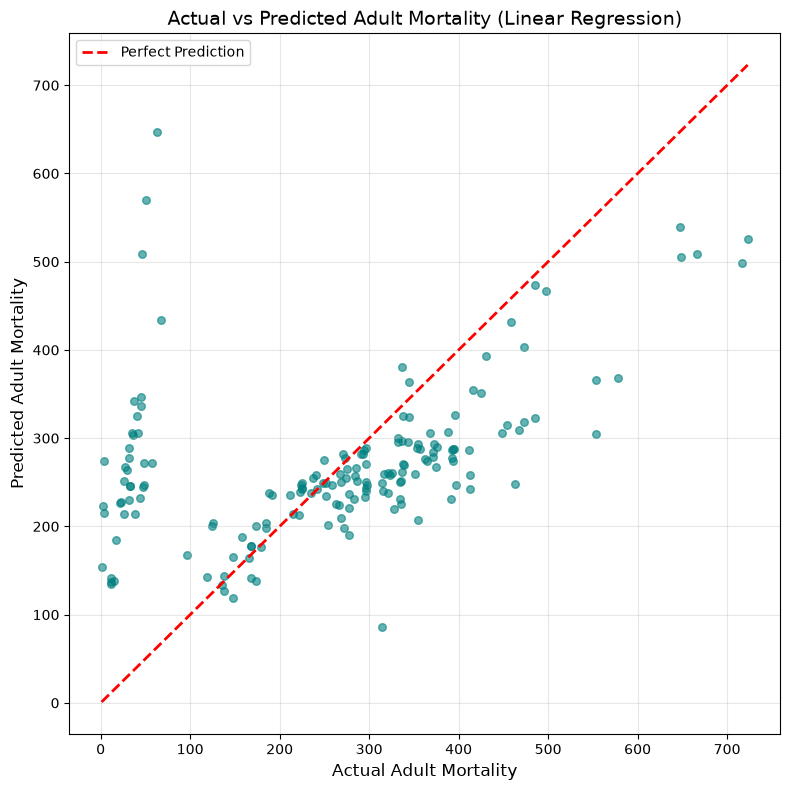

In [29]:
# Also show Actual vs Predicted scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(y_test, lr_test_pred, alpha=0.6, color='teal', s=30)

# Perfect prediction line
min_val = min(y_test.min(), lr_test_pred.min())
max_val = max(y_test.max(), lr_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Adult Mortality', fontsize=12)
plt.ylabel('Predicted Adult Mortality', fontsize=12)
plt.title('Actual vs Predicted Adult Mortality (Linear Regression)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Save the Best Performing Model

Based on the comparison, I will save the model with the lowest test MSE.

In [30]:
# Determine which model performed best
all_models = {
    'SGD Linear Regression': (sgd_model, mean_squared_error(y_test, sgd_test_pred)),
    'Linear Regression (OLS)': (lr_model, mean_squared_error(y_test, lr_test_pred)),
    'Random Forest': (rf_model, mean_squared_error(y_test, rf_test_pred)),
    'Decision Tree': (dt_model, mean_squared_error(y_test, dt_test_pred)),
}

best_name = min(all_models, key=lambda k: all_models[k][1])
best_model = all_models[best_name][0]
best_mse = all_models[best_name][1]

print(f"Best performing model: {best_name}")
print(f"Test MSE: {best_mse:.2f}")
print(f"\nCriteria: The model with the lowest Mean Squared Error on test data was selected.")
print(f"Lower MSE means the model's predictions are closer to the actual values on average.")

Best performing model: Random Forest
Test MSE: 18231.76

Criteria: The model with the lowest Mean Squared Error on test data was selected.
Lower MSE means the model's predictions are closer to the actual values on average.


In [31]:
# Save the best model and the scaler (needed for new predictions)
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Also save the feature column names so the API knows what inputs to expect
feature_columns = list(X.columns)
joblib.dump(feature_columns, 'feature_columns.pkl')

print(f"Model saved as: best_model.pkl")
print(f"Scaler saved as: scaler.pkl")
print(f"Feature columns saved as: feature_columns.pkl")
print(f"\nFeatures the model expects: {feature_columns}")

Model saved as: best_model.pkl
Scaler saved as: scaler.pkl
Feature columns saved as: feature_columns.pkl

Features the model expects: ['Year', 'Status', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', 'Income composition of resources', 'Schooling']


## 10. Make a Prediction (Single Data Point)

Let me test the saved model by predicting on one row from the test dataset.

In [32]:
# Load the saved model (simulating what the API will do)
loaded_model = joblib.load('best_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
loaded_features = joblib.load('feature_columns.pkl')

In [33]:
# Pick one row from the test set
sample_row = X_test.iloc[0]
actual_value = y_test.iloc[0]

print("Input values for prediction:")
print("=" * 45)
for col, val in sample_row.items():
    print(f"  {col}: {val}")

Input values for prediction:
  Year: 2009.0
  Status: 0.0
  infant deaths: 7.0
  Alcohol: 3.47
  percentage expenditure: 0.0
  Hepatitis B: 75.0
  Measles : 1.0
   BMI : 23.9
  Polio: 76.0
  Total expenditure: 2.27
  Diphtheria : 78.0
   HIV/AIDS: 4.0
  GDP: 533.8702170500001
  Population: 1581720.0
   thinness  1-19 years: 8.3
  Income composition of resources: 0.545
  Schooling: 10.3


In [34]:
# Make the prediction
sample_scaled = loaded_scaler.transform([sample_row.values])
predicted_value = loaded_model.predict(sample_scaled)[0]

print(f"\nActual Adult Mortality: {actual_value}")
print(f"Predicted Adult Mortality: {predicted_value:.2f}")
print(f"Difference: {abs(actual_value - predicted_value):.2f}")


Actual Adult Mortality: 314.0
Predicted Adult Mortality: 317.68
Difference: 3.68


## Summary

In this notebook, we:
1. Loaded the WHO Life Expectancy dataset and filtered it for **African nations**
2. Performed EDA with correlation heatmaps and scatter plots
3. Engineered features by dropping correlated columns and encoding categorical data
4. Standardized all features using StandardScaler
5. Trained and compared **4 regression models**: SGD, OLS, Random Forest, and Decision Tree
6. Plotted the loss curve for SGD training
7. Created before-and-after scatter plots showing the regression line
8. Saved the best performing model for use in our API